## **Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import warnings

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_squared_error, r2_score, mean_squared_log_error

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
palette_color = sns.color_palette("pastel")

## **Load Processed Data**

In [3]:
df_raw = pd.read_csv("dataset/raw/train.csv")

In [6]:
df_processed = pd.read_csv("dataset/processed/train_processed.csv")

In [25]:
df_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2492096 entries, 0 to 2492095
Data columns (total 17 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Temperature(F)     float64
 1   Humidity(%)        float64
 2   Visibility(mi)     float64
 3   Amenity            bool   
 4   City               object 
 5   County             object 
 6   Crossing           bool   
 7   Junction           bool   
 8   Railway            bool   
 9   Start_Time         object 
 10  State              object 
 11  Station            bool   
 12  Stop               bool   
 13  Sunrise_Sunset     object 
 14  Traffic_Signal     bool   
 15  Weather_Condition  object 
 16  Severity           int64  
dtypes: bool(7), float64(3), int64(1), object(6)
memory usage: 206.8+ MB


In [26]:
pd.set_option('display.max_columns', None)
df_processed.head()

,Temperature(F),Humidity(%),Visibility(mi),Amenity,City,County,Crossing,Junction,Railway,Start_Time,State,Station,Stop,Sunrise_Sunset,Traffic_Signal,Weather_Condition,Severity
0,63.0,66.0,10.0,False,Hillsborough,Orange,False,False,False,2022-03-18 06:55:00,NC,False,False,Night,False,Cloudy,4
1,41.0,93.0,10.0,False,Auburn,Placer,False,False,False,2023-01-29 16:35:00,CA,False,True,Day,False,Cloudy,2
2,71.0,32.0,10.0,False,Richmond,Richmond City,True,False,False,2022-10-11 12:53:40,VA,False,False,Day,True,Fair,2
3,26.0,99.0,10.0,False,Newport News,Newport News,False,True,False,2022-01-24 06:12:00,VA,False,False,Night,False,Fair,2
4,64.0,52.0,10.0,False,Sacramento,Sacramento,False,True,False,2020-02-14 15:28:00,CA,False,False,Day,False,Fair,2


## Columns Split

In [27]:
numerical_vars = df_processed.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_vars = df_processed.select_dtypes(include=['object']).columns.tolist()
boolean_vars = df_processed.select_dtypes(include=['bool']).columns.tolist()

In [28]:
print("\nNumerical Columns:", numerical_vars)
print("\nCategorical Columns:", categorical_vars)
print("\nBoolean Columns:", boolean_vars)


Numerical Columns: ['Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Severity']

Categorical Columns: ['City', 'County', 'Start_Time', 'State', 'Sunrise_Sunset', 'Weather_Condition']

Boolean Columns: ['Amenity', 'Crossing', 'Junction', 'Railway', 'Station', 'Stop', 'Traffic_Signal']


In [29]:
numerical_data = df_processed[numerical_vars]
print ("Numerical Data Description:")
numerical_data.describe().round(2)

Numerical Data Description:


,Temperature(F),Humidity(%),Visibility(mi),Severity
count,2492096.00,2492096.00,2492096.00,2492096.00
mean,60.96,63.74,9.09,2.08
std,19.03,22.79,2.57,0.41
min,-50.00,1.00,0.00,1.00
25%,49.00,47.00,10.00,2.00
50%,63.00,66.00,10.00,2.00
75%,75.00,83.00,10.00,2.00
max,130.00,100.00,140.00,4.00


In [30]:
categorical_data = df_processed[categorical_vars]
print ("Categorical Data Description:")
categorical_data.describe().round(2)

Categorical Data Description:


,City,County,Start_Time,State,Sunrise_Sunset,Weather_Condition
count,2492096,2492096,2492096,2492096,2492096,2492096
unique,11521,1745,1636414,49,2,122
top,Miami,Los Angeles,2021-01-26 16:16:13,CA,Day,Fair
freq,92617,183782,181,659581,1593692,1157228


In [31]:
boolean_data = df_processed[boolean_vars]
print ("Boolean Data Description:")
boolean_data.describe().round(2)

Boolean Data Description:


,Amenity,Crossing,Junction,Railway,Station,Stop,Traffic_Signal
count,2492096,2492096,2492096,2492096,2492096,2492096,2492096
unique,2,2,2,2,2,2,2
top,False,False,False,False,False,False,False
freq,2464177,2260487,2290332,2472483,2424135,2428371,2259034


## **Check for Missing Values**

In [32]:
missing_count = missing_count = df_processed.isnull().sum()
missing_percent = (missing_count / len(df_processed) * 100).round(2)
pd.DataFrame({'Missing Count': missing_count, 'Missing Percent': missing_percent}).sort_values(by='Missing Percent', ascending=False)   

,Missing Count,Missing Percent
Temperature(F),0,0.0
Humidity(%),0,0.0
Visibility(mi),0,0.0
Amenity,0,0.0
City,0,0.0
County,0,0.0
Crossing,0,0.0
Junction,0,0.0
Railway,0,0.0
Start_Time,0,0.0


After cleaning the dataset, all selected variables show 0 missing values, meaning the data is now fully complete across every field. This ensures that subsequent analysis, modeling, and visualization can proceed without the need for imputation or additional preprocessing related to missing data.

## Outlier Detection

In [33]:
# Detect outliers using the IQR method
Q1 = df_processed[numerical_vars].quantile(0.25)
Q3 = df_processed[numerical_vars].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df_processed[numerical_vars] < (Q1 - 1.5 * IQR)) | 
              (df_processed[numerical_vars] > (Q3 + 1.5 * IQR))).sum()

print("Number of outliers (per column):\n", outliers)

Number of outliers (per column):
 Temperature(F)     22123
Humidity(%)            0
Visibility(mi)    462300
Severity          169713
dtype: int64


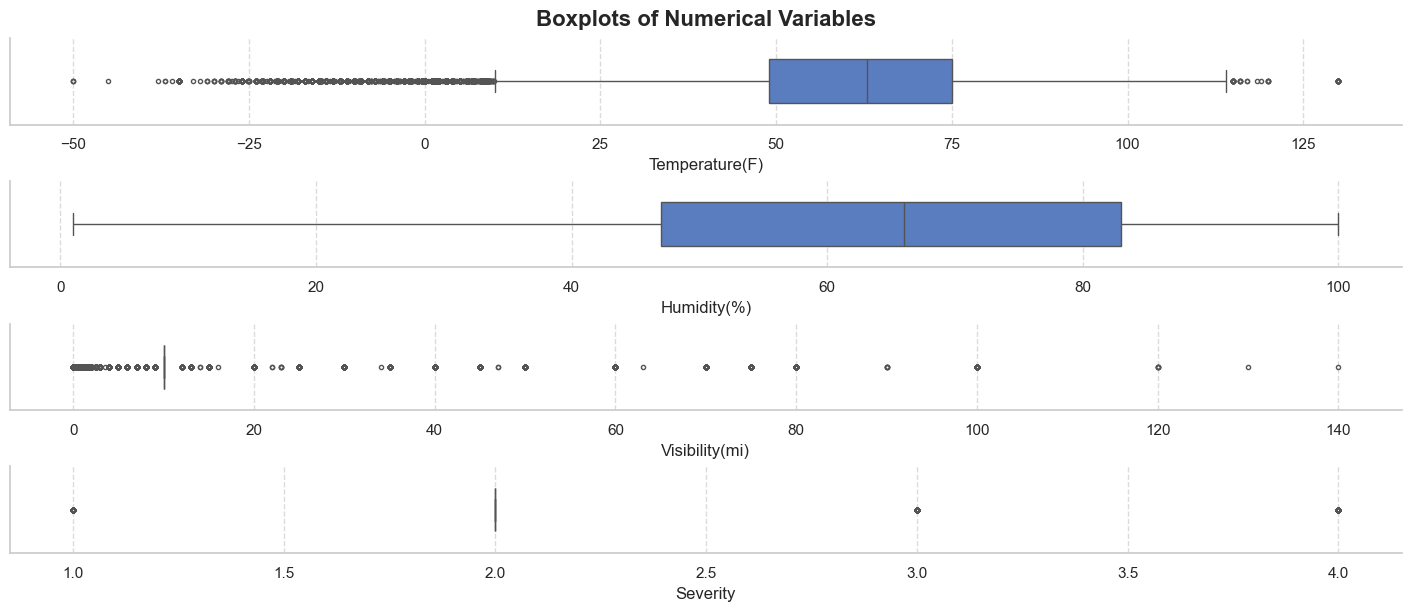

In [ ]:
sns.set_style("whitegrid")

plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.bottom'] = True

n = len(numerical_vars)

fig, axes = plt.subplots(n, 1, figsize=(14, n * 1.5), constrained_layout=True)

consistent_color = sns.color_palette("muted")[0] 

for i, col in enumerate(numerical_vars):
    ax = axes[i] if n > 1 else axes
    
    sns.boxplot(
        x=df_processed[col],
        orient='h',
        color=consistent_color,
        ax=ax,
        width=0.5,
        fliersize=3
    )

    ax.set_xlabel(col, fontsize=12) 
    ax.set_ylabel("")

    ax.grid(axis='y', visible=False) 
    ax.grid(axis='x', linestyle='--', alpha=0.7)

fig.suptitle("Boxplots of Numerical Variables", fontsize=16, fontweight='bold')

plt.show()

After cleaning, the number of outliers decreases in some fields (**Temperature(F), Severity**) due to transformations or filtering.
However, **Visibility(mi)** still contains many outliers. These values were not removed intentionally, because low visibility is a realistic condition in accident scenarios and directly contributes to crash risk. These are meaningful observations, not invalid data points, so they remain in the dataset.

## VIF Check

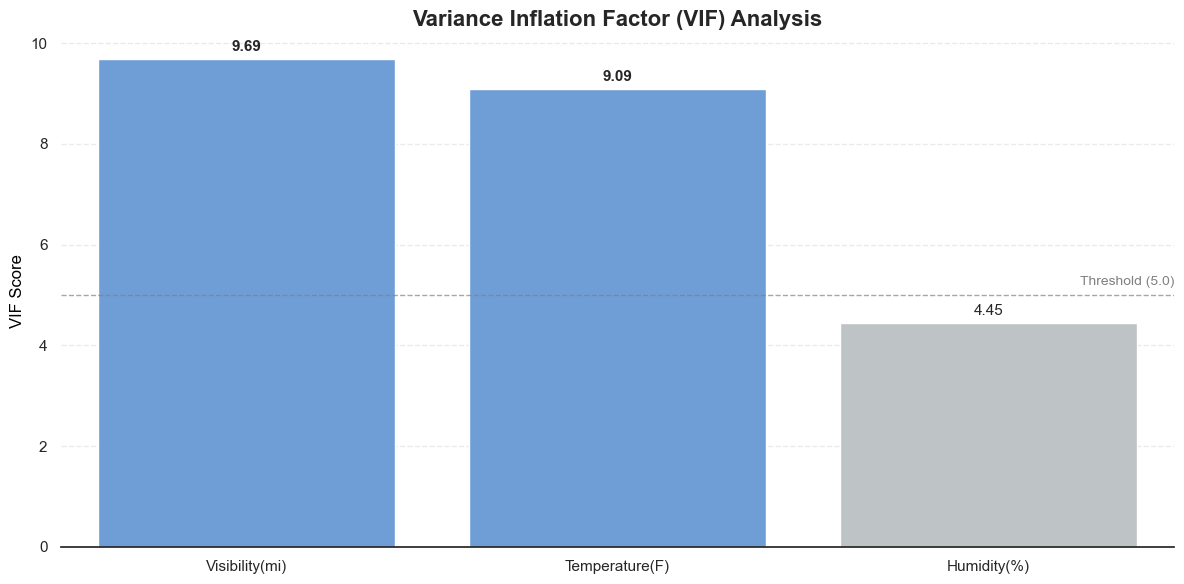

In [39]:
target_var = 'Severity'
X_numeric = df_processed[numerical_vars].drop(columns=[target_var])

vif_data = pd.DataFrame()
vif_data['Feature'] = X_numeric.columns
vif_data['VIF'] = [variance_inflation_factor(X_numeric.dropna().values, i) 
                   for i in range(X_numeric.shape[1])]
vif_data = vif_data.sort_values(by='VIF', ascending=False)

sns.set_style("white")

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#5e9ce8' if x >= 5 else '#bdc3c7' for x in vif_data['VIF']]

sns.barplot(x='Feature', y='VIF', data=vif_data, palette=colors, ax=ax)

for p in ax.patches:
    height = p.get_height()
    weight = 'bold' if height >= 5 else 'normal'
    ax.text(p.get_x() + p.get_width()/2., height + 0.1, 
            f'{height:.2f}', 
            ha='center', va='bottom', fontsize=11, fontweight=weight)

ax.axhline(y=5, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.text(len(vif_data)-0.5, 5.2, 'Threshold (5.0)', color='gray', fontsize=10, ha='right')

sns.despine(left=True, bottom=False)

ax.set_ylabel('VIF Score', fontsize=12, color='black')
ax.set_xlabel('')
ax.set_title('Variance Inflation Factor (VIF) Analysis', fontsize=16, fontweight='bold', loc='center')

ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.tick_params(axis='x', labelsize=11)

plt.tight_layout()
plt.show()

After cleaning and processing, only three core numeric features remained for VIF testing.
- **Visibility** and **Temperature** have VIF close to 10, showing strong multicollinearity, meaning these weather variables still influence each other even after processing.
- **Humidity** has moderate correlation.
> Overall, the processed dataset is cleaner but still shows expected relationships between weather metrics.

## **Univariate Analysis**

## Numerical features distribution

In [40]:
def plot_comparison_hist(column, df1, df2, color1="#5e9ce8", color2='#ff9f1c', figsize=(14,6)):
    sns.set_style("white") 
    
    fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)

    x_min = min(df1[column].min(), df2[column].min())
    x_max = max(df1[column].max(), df2[column].max())

    data_pairs = [
        (axes[0], df1, 'Raw Data', color1),
        (axes[1], df2, 'Processed Data', color2)
    ]
    
    for ax, df, suffix, color in data_pairs:
        sns.histplot(df[column], kde=True, bins=50, ax=ax, 
                     color=color, alpha=0.6, edgecolor='white', linewidth=0.5)

        mean_val = df[column].mean()
        median_val = df[column].median()

        ax.axvline(mean_val, color='#d62728', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
        ax.axvline(median_val, color='#2ca02c', linestyle='-', linewidth=1.5, label=f'Median: {median_val:.2f}')

        ax.set_title(f'{column} ({suffix})', fontsize=14, color='#333333', loc='left', pad=15)

        ax.set_xlabel(column, fontsize=11, color='black')
        ax.set_ylabel('Frequency' if ax == axes[0] else '', fontsize=11, color='black')

        ax.grid(axis='y', linestyle='--', alpha=0.4)

        sns.despine(ax=ax)

        ax.legend(loc='upper right', frameon=False, fontsize=10)

        ax.set_xlim(x_min, x_max)

    fig.suptitle(f"Distribution Comparison: {column}", fontsize=16, fontweight='bold', y=1.05)
    
    plt.show()

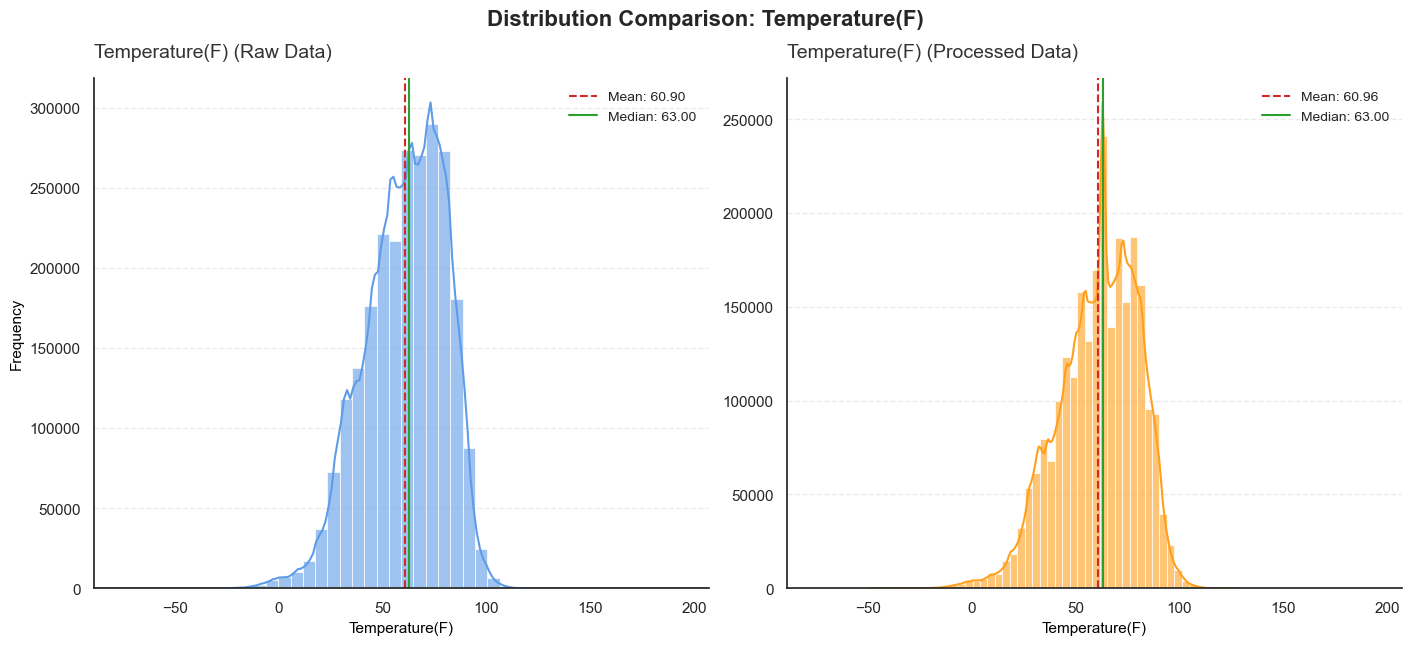

In [41]:
plot_comparison_hist('Temperature(F)', df_raw, df_processed)

### Temperature(F) – Data After Processing Review
**Preservation of Data Distribution**
- Outlier capping and missing value imputation successfully cleaned the data while preserving its integrity.
- The overall bell-curve shape is maintained after preprocessing, showing that the data’s underlying structure was not distorted.  
- Statistical stability:
  - **Mean:** 60.90 → 60.96  
  - **Median:** 63.00 (unchanged)  
  These minimal changes confirm that the preprocessing was accurate and light-touch.

**Explanation of Distribution Changes**
- Tail truncation due to outlier capping: 
  - **Raw data:** Long tails at both ends, including physically impossible extremes.  
  - **Processed data:** Extreme values capped at the defined boundaries.  
- Visual effect: The histogram of processed data appears more compact, with steeper sides at the edges due to removed outliers.

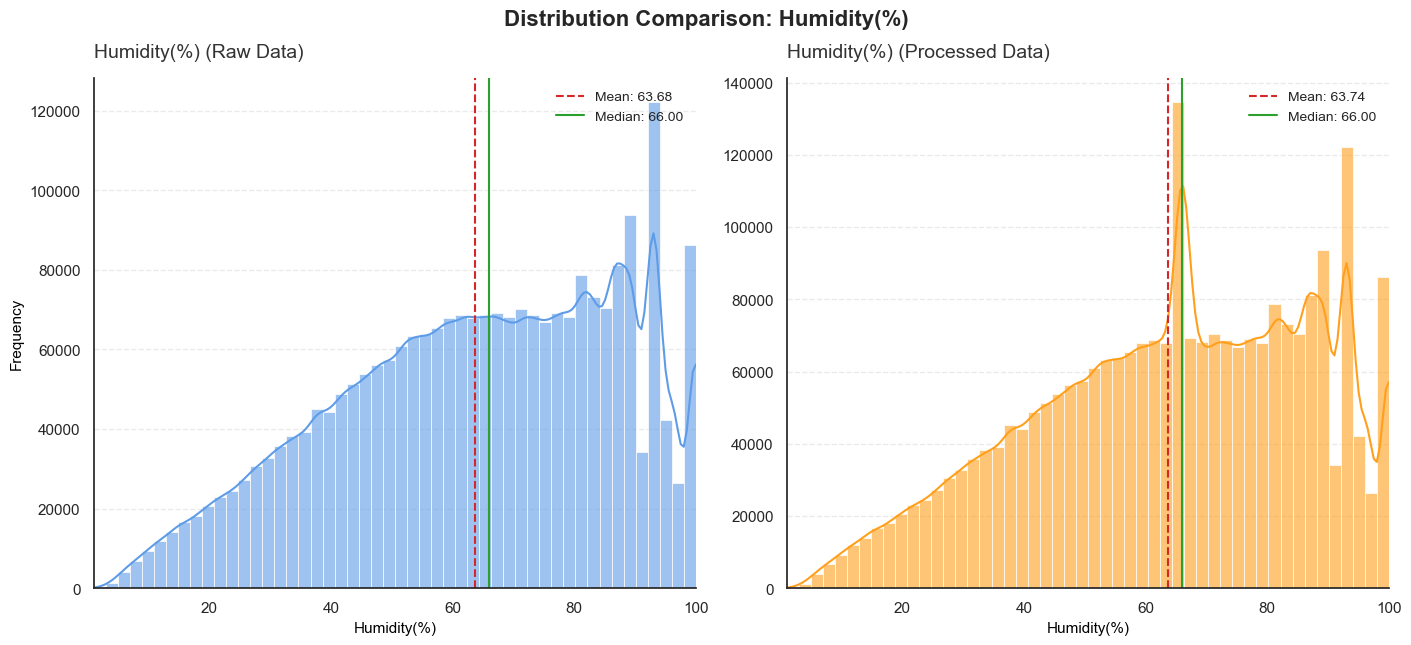

In [42]:
plot_comparison_hist('Humidity(%)', df_raw, df_processed)

### Humidity(%) – Data After Processing Review
**Preservation of Data Distribution**
- The data processing procedure, which included filling in missing values ​​with Median and handling outliers with Capping/Winsorization, worked very well. The overall shape of the data remains intact, without distortion, ensuring that the physical nature of the Humidity is not altered.
- Statistical stability:
  - **Mean:** 63.68 → 63.74 
  - **Median:** 66.00 (unchanged)  

**Explanation of Distribution Changes**
The processed histogram shows a sharp spike at the median value (Median ≈ 66%), forming a noticeable “peak” compared to the original histogram. This spike results from imputing missing values with the median. All NaN values were replaced with 66%, which significantly increased the frequency of this value.

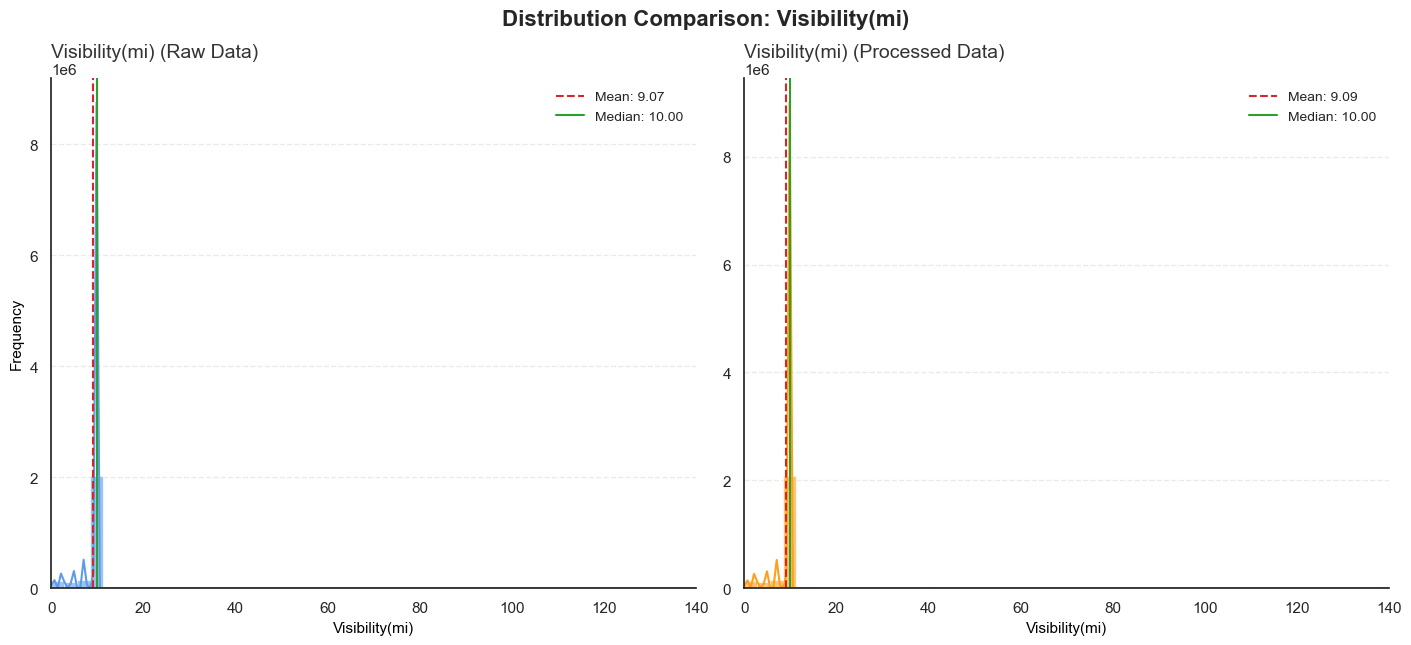

In [43]:
plot_comparison_hist('Visibility(mi)', df_raw, df_processed)

### Visibility (mi) – Data After Processing Review

**Visibility (mi)**
Before treatment: distribution is very right skewed — mostly concentrated at low levels (near 10 mi or lower) but there are some large outliers causing long tails; mean ≈ 9.07, median = 10.

After treatment: mean ≈ 9.09, median = 10 — center unchanged; post-treatment distribution is similarly right skewed but density curve is smoother, extremely large tails may have been treated/denoised.

> Treatment did not change the center position, but cleaned up large outliers/unwanted fluctuations.


## Categorical features distribution

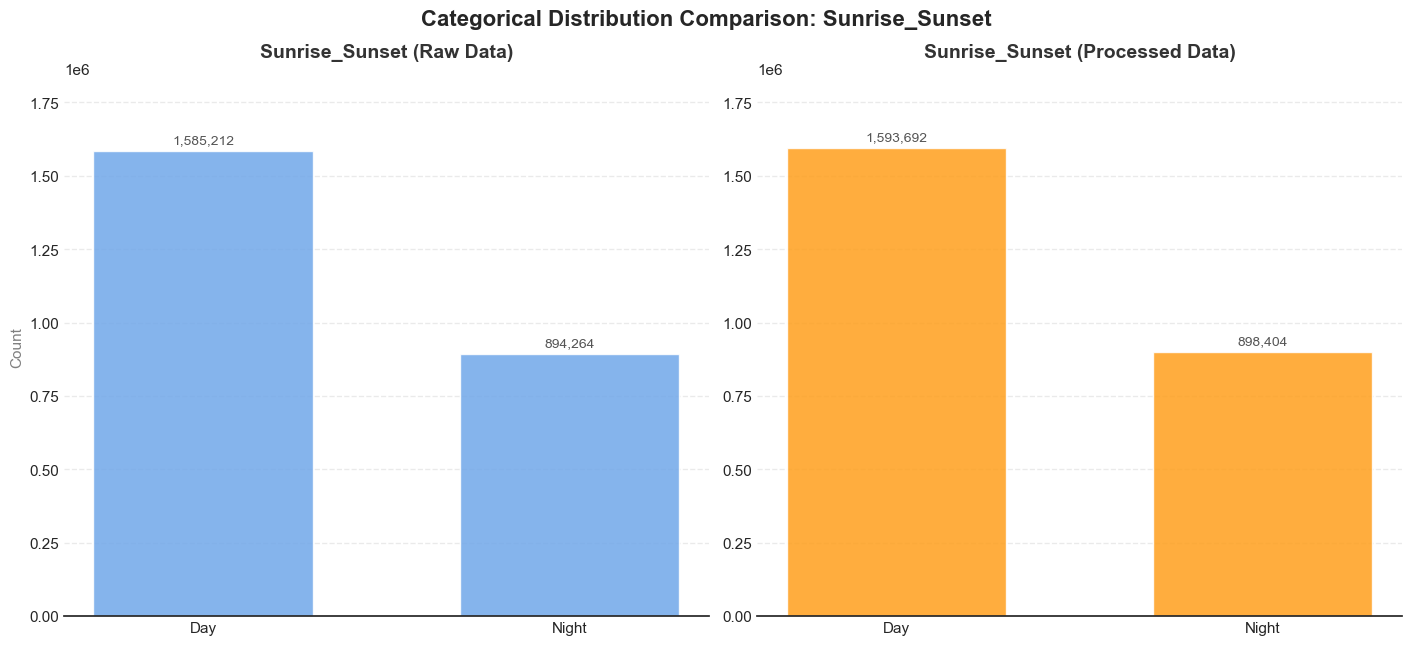

In [54]:
def plot_categorical_comparison(column, df1, df2, color1="#70a7e9", color2='#ff9f1c', figsize=(14, 6)):
    sns.set_style("white")

    u1 = df1[column].dropna().unique()
    u2 = df2[column].dropna().unique()

    unique_vals = set(u1) | set(u2)

    categories = sorted(list(unique_vals), key=str)

    count1 = df1[column].value_counts().max()
    count2 = df2[column].value_counts().max()

    if np.isnan(count1): count1 = 0
    if np.isnan(count2): count2 = 0
        
    max_count = max(count1, count2)
    ylim_max = max_count * 1.15
    
    fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)
    
    data_pairs = [
        (axes[0], df1, 'Raw Data', color1),
        (axes[1], df2, 'Processed Data', color2)
    ]
    
    for ax, df, suffix, color in data_pairs:

        counts = df[column].value_counts().reindex(categories, fill_value=0)

        x_labels = [str(x) for x in categories]
        bars = ax.bar(x_labels, counts, color=color, alpha=0.85, width=0.6)

        ax.set_title(f'{column} ({suffix})', fontsize=14, color='#333333', loc='center', pad=15, fontweight='bold')
        
        ax.set_xlabel('') 
        if ax == axes[0]:
            ax.set_ylabel('Count', fontsize=11, color='gray')
        else:
            ax.set_ylabel('') 

        ax.set_ylim(0, ylim_max)

        ax.grid(axis='y', linestyle='--', alpha=0.4)
        ax.set_axisbelow(True) 

        sns.despine(ax=ax, left=True) 

        ax.tick_params(axis='y', length=0)
        ax.tick_params(axis='x', labelsize=11, length=0)

        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2., height + (max_count*0.01), 
                        f'{int(height):,}', 
                        ha='center', va='bottom', fontsize=10, color='#555555')

    fig.suptitle(f"Categorical Distribution Comparison: {column}", fontsize=16, fontweight='bold', y=1.05)
    plt.show()

plot_categorical_comparison('Sunrise_Sunset', df_raw, df_processed)

### Sunset_Sunrise – Data After Processing Review
**Preservation of Data Distribution**
- In both stages, the number of records occurring during the Day is nearly twice as high as those at Night. This indicates that accidents or events in the dataset tend to happen more frequently during daytime. 
- After handling missing values, the number of records increases slightly. This uniform increase demonstrates that the imputation or cleaning process did not distort the original distribution, ensuring safe and unbiased data handling.

**Explanation of Distribution Unchanges**
The Day/Night ratio remains almost unchanged. This confirms that the missing-value treatment did not introduce any new bias into the dataset.

## **Multivariate Analysis**

In [66]:
df_processed.head()

,Temperature(F),Humidity(%),Visibility(mi),Amenity,City,County,Crossing,Junction,Railway,Start_Time,State,Station,Stop,Sunrise_Sunset,Traffic_Signal,Weather_Condition,Severity
0,63.0,66.0,10.0,False,Hillsborough,Orange,False,False,False,2022-03-18 06:55:00,NC,False,False,Night,False,Cloudy,4
1,41.0,93.0,10.0,False,Auburn,Placer,False,False,False,2023-01-29 16:35:00,CA,False,True,Day,False,Cloudy,2
2,71.0,32.0,10.0,False,Richmond,Richmond City,True,False,False,2022-10-11 12:53:40,VA,False,False,Day,True,Fair,2
3,26.0,99.0,10.0,False,Newport News,Newport News,False,True,False,2022-01-24 06:12:00,VA,False,False,Night,False,Fair,2
4,64.0,52.0,10.0,False,Sacramento,Sacramento,False,True,False,2020-02-14 15:28:00,CA,False,False,Day,False,Fair,2


## Location Features vs Severity

In [7]:
def plot_categorical_comparison(df1, df2, categorical_cols, colors=None, top_n=10):
    colors = colors or ["#F32308", "#FF5D47", "#FFB5AD", "#FFE3E0"]
    
    for feature in categorical_cols:
        fig, axes = plt.subplots(1, 2, figsize=(18, 6))
        
        for ax, df, title in zip(axes, [df1, df2], ['Raw', 'Processed']):
            if df[feature].nunique() > top_n:
                top_categories = df[feature].value_counts().head(top_n).index[::-1]
                plot_df = df[df[feature].isin(top_categories)]
                title_suffix = f' (Top {top_n})'
            else:
                plot_df = df
                top_categories = None
                title_suffix = ''
            
            severity_counts = plot_df.groupby([feature, 'Severity']).size().unstack(fill_value=0)
            if top_categories is not None:
                severity_counts = severity_counts.reindex(top_categories)
            severity_counts = severity_counts.reindex(columns=[1,2,3,4], fill_value=0)[[4,3,2,1]]
            
            severity_counts.plot(kind='barh', ax=ax, stacked=False, logx=True, width=0.8, color=colors)
            ax.set_title(f'{feature} vs Severity - {title}{title_suffix}', fontsize=14, fontweight='bold')
            ax.set_xlabel('Count (Log Scale)', fontweight='bold')
            ax.set_ylabel(feature, fontweight='bold')
            ax.grid(axis='x', alpha=0.3)
            handles, labels = ax.get_legend_handles_labels()
            ax.legend(handles[::-1], labels[::-1], title='Severity', fontsize=9, loc='lower right')
        
        plt.tight_layout()
        plt.show()

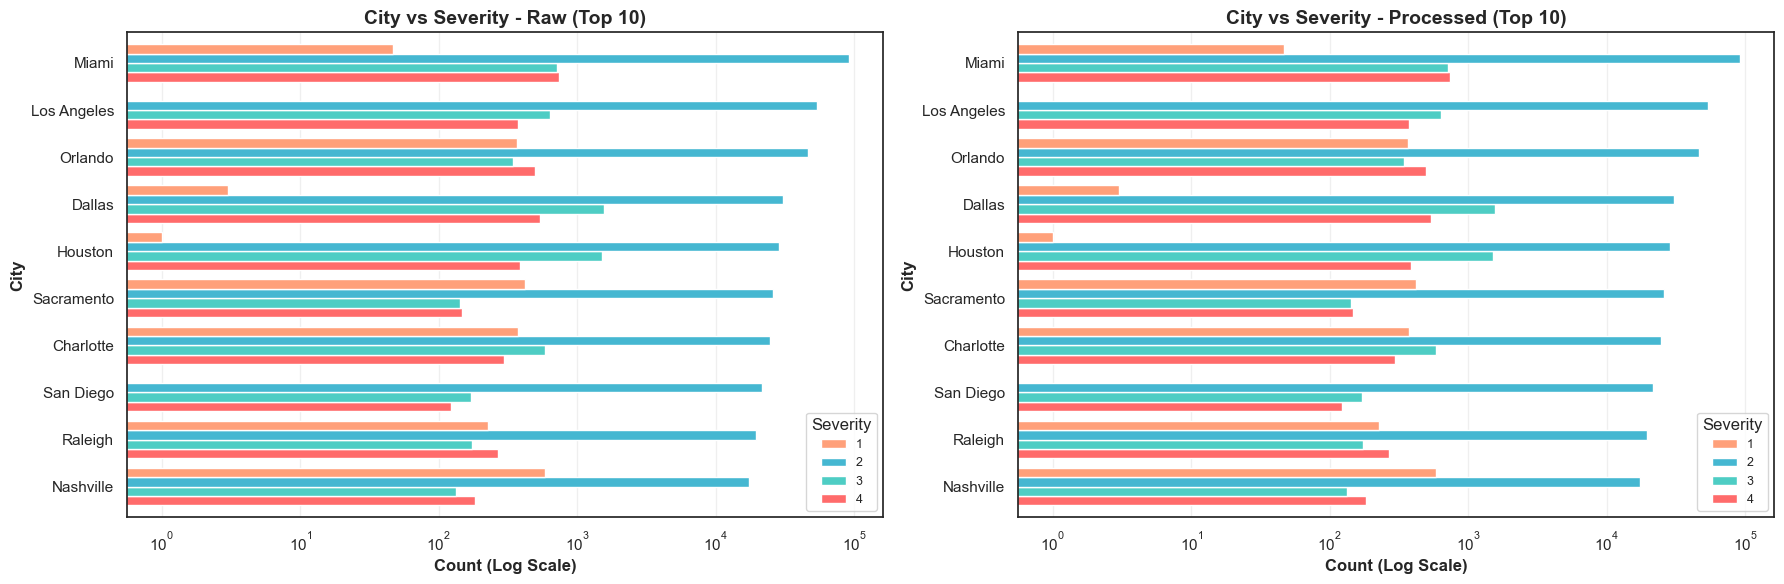

In [80]:
plot_categorical_comparison(df_raw, df_processed, ['City'])

- **Data Quality Check**
    + Stability (Consistency): The rankings and proportions of cities in the Processed chart are almost identical to those in the Raw data.
    + Information Preservation: The lengths of the bars in the chart show no sudden drops. This confirms that the data cleaning process (handling Missing Values, standardizing names) has preserved the core geographic structure of the dataset without distorting the real distribution.
- **Severity Distribution Analysis**
    + Dominance of Severity 2: In most major cities (such as Miami, Los Angeles...), Severity 2 is the most dominant group. This is a common feature of traffic accident data in urban areas (usually minor collisions, local congestion).
    + Severity 3 & 4: Thanks to the logarithmic scale, we can clearly see the presence of more serious accidents (Severity 3, 4). Although their numbers are hundreds of times fewer than Severity 2, they still consistently appear in large cities, reflecting the actual risk at busy intersections.

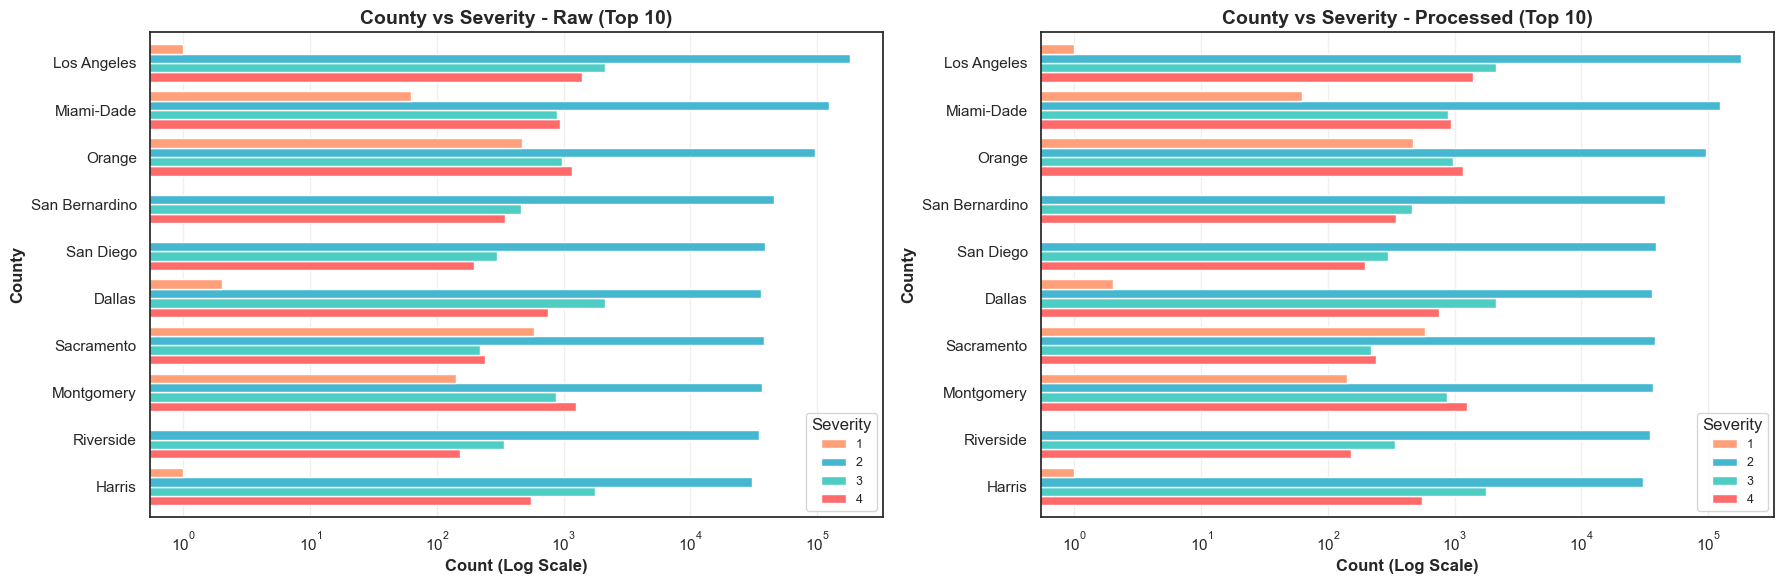

In [81]:
plot_categorical_comparison(df_raw, df_processed, ['County'])

- **Data Stability**
    + Processing Results: The data structure is fully preserved. The rankings of major Counties (e.g., Los Angeles County, Miami-Dade County...) remain unchanged after the preprocessing step.
    + Meaning: The data processing (such as filling missing values) does not distort the regional geographic characteristics.
- **Difference Compared to the City Feature**: Unlike the City feature (which tends to be fragmented into smaller segments), the County feature has a higher level of aggregation:
    + Broader Coverage: A County typically includes multiple cities and even inter-county highway areas (unincorporated areas). Therefore, County-level data provides a more accurate reflection of the traffic management area.
    + Higher Density: The number of accidents in top Counties is usually more "concentrated" compared to top Cities, making it easier for the model to learn the broader patterns.
- **Severity Analysis**
    + Severity 2 Dominance: Similar to the city level, at the County level, Severity 2 still dominates overwhelmingly.
    + Severity 3 & 4: By aggregating data at the County level, the number of Severity 4 incidents becomes more statistically significant compared to when data is broken down by city. This makes it easier to observe "hot spots" for serious accidents.

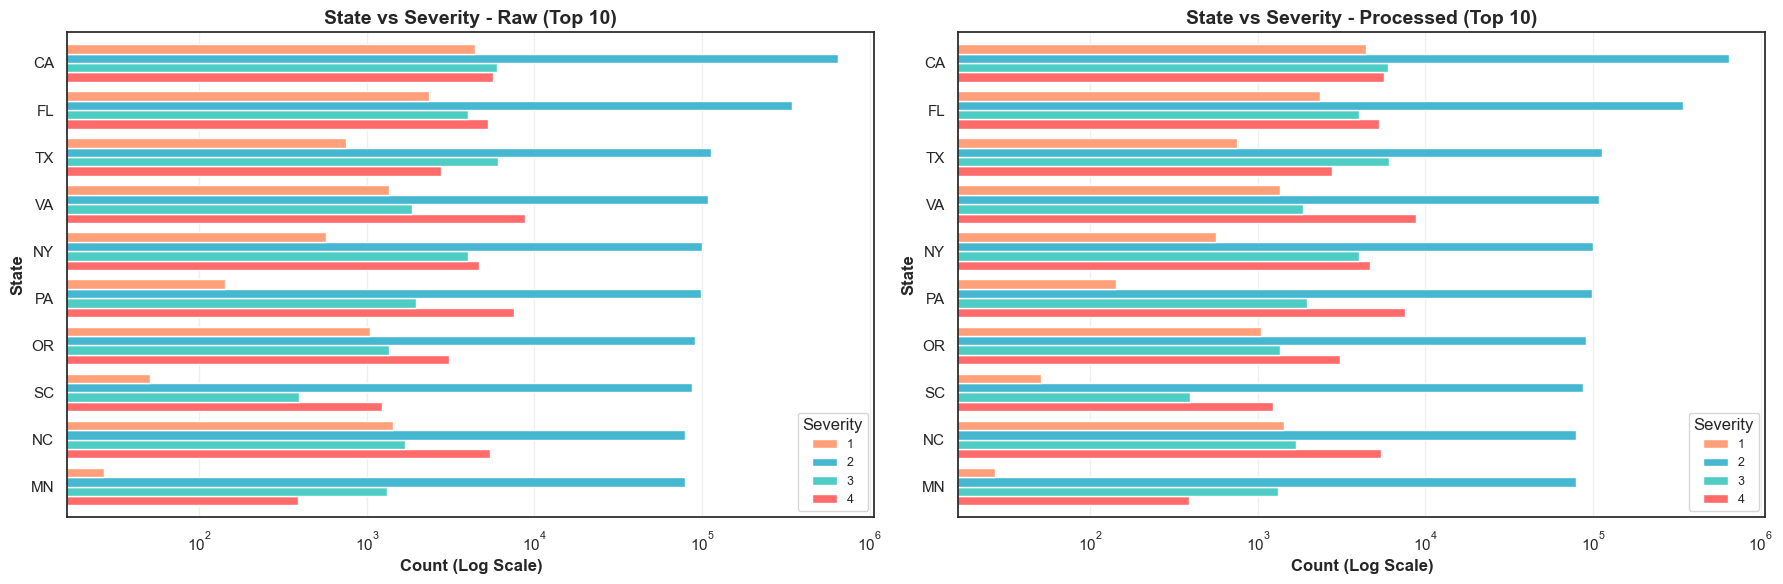

In [82]:
plot_categorical_comparison(df_raw, df_processed, ['State'])

- **Data Verification (Data Integrity):** The ranking of states with the highest number of accidents (usually CA - California, TX - Texas, FL - Florida) should remain consistent between the two charts.
- **Geographic Distribution Characteristics**
    + Significant Imbalance: Data tends to be heavily concentrated in the top 3-5 most populous states with complex transportation systems (CA, TX, FL, NY).
    + Data Collection Factors: It's important to note that the high number of accidents in CA or TX may not only be due to population size but also because of better data sources in these regions, with more comprehensive traffic sensor systems than in other states.
- **Severity Analysis by State**
    + Severity 2 Dominates: Similar to cities and counties, Severity 2 accidents still account for the vast majority across all states.
    + Differences in Severity 3 & 4 Rates:
        + Some states with mountainous terrain or harsh climates (snow, ice) may have higher rates of Severity 3 or 4 accidents compared to flat states.
        + These differences suggest that the State feature is not only an administrative location but also a proxy feature for climate, terrain, and local traffic laws.

**Insight:** The State feature serves as a baseline feature. However, for accurate severity prediction, the model must incorporate additional features like weather conditions and time of day. The state name itself (e.g., "California") does not cause accidents—factors like "fog in California at 8 AM" are the actual causes.

## Road Condition feature vs Severity

### Road Condition Feature – Data After Processing Review

The Boolean variables in the dataset — **Amenity, Crossing, Junction, Railway, Station, Stop, Traffic_Signal** — show consistent behavior before and after data processing.

Key Points
- These variables contain no missing values.
- They have no outliers (only True/False values).
- The processing step does not alter their distributions.

Conclusion
> Since the Boolean features remain unchanged after preprocessing, re-plotting their charts is unnecessary, and all original insights remain valid without modification.

## Weather feature vs Severity

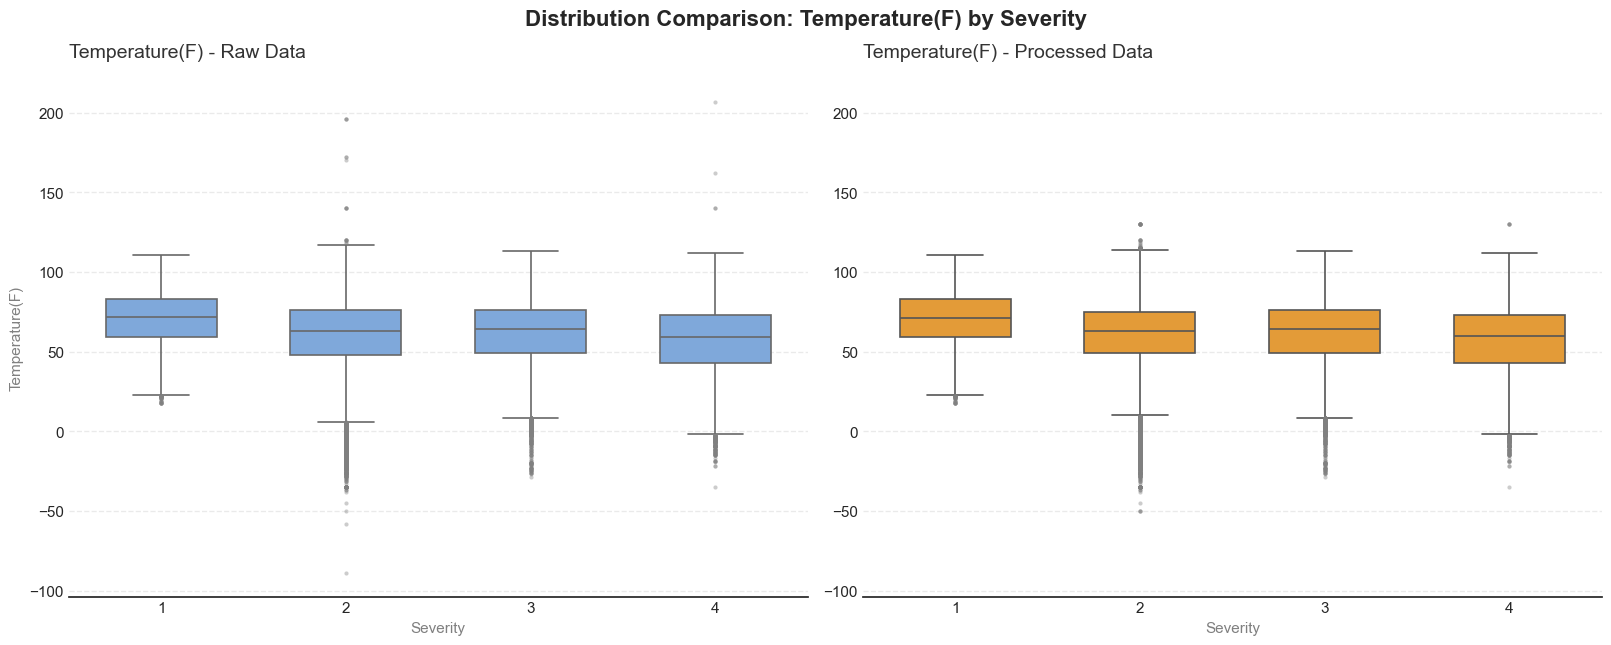

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_numerical_comparison(df1, df2, numerical_cols, colors=None):
    # 1. Cấu hình Style sạch sẽ
    sns.set_style("white")
    
    # Màu sắc nhất quán với các biểu đồ trước
    colors = colors or ['#70a7e9', '#ff9f1c']
    
    # Cấu hình cho điểm ngoại lai (Outliers) để giảm bớt sự lộn xộn (Chart Junk)
    # Làm nhỏ, đổi màu xám và tăng độ trong suốt
    flier_props = dict(marker='o', markerfacecolor='gray', markersize=3,
                       linestyle='none', markeredgecolor='none', alpha=0.4)
    
    for col in numerical_cols:
        # Tính toán giới hạn trục Y chung cho cả 2 biểu đồ (Scale Consistency)
        # Để đảm bảo người xem so sánh được độ nén/giãn của dữ liệu thực tế
        y_min = min(df1[col].min(), df2[col].min())
        y_max = max(df1[col].max(), df2[col].max())
        y_range = y_max - y_min
        ylim = (y_min - y_range*0.05, y_max + y_range*0.05) # Thêm 5% padding
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
        
        data_pairs = [
            (axes[0], df1, 'Raw Data', colors[0]),
            (axes[1], df2, 'Processed Data', colors[1])
        ]
        
        for ax, df, suffix, color in data_pairs:
            sns.boxplot(
                data=df,
                x='Severity',
                y=col,
                ax=ax,
                color=color,
                width=0.6, # Thu hẹp hộp để tạo khoảng trắng (Proximity)
                linewidth=1.2,
                flierprops=flier_props # Áp dụng style cho outlier
            )
            
            # 2. Tinh chỉnh Design (HubSpot & Lesson 10)
            ax.set_title(f'{col} - {suffix}', fontsize=14, color='#333333', loc='left', pad=15)
            
            # Labels: Bỏ in đậm, dùng màu nhạt
            ax.set_xlabel('Severity', fontsize=11, color='gray')
            if ax == axes[0]:
                ax.set_ylabel(col, fontsize=11, color='gray')
            else:
                ax.set_ylabel('') # Bỏ nhãn trục Y bên phải cho thoáng
            
            # Thiết lập trục Y chung
            ax.set_ylim(ylim)
            
            # Grid & Spines
            ax.grid(axis='y', linestyle='--', alpha=0.4)
            sns.despine(ax=ax, left=True) # Bỏ trục dọc bên trái
            
            # Ticks
            ax.tick_params(axis='y', length=0)
            ax.tick_params(axis='x', length=0)

        # Tiêu đề tổng
        fig.suptitle(f'Distribution Comparison: {col} by Severity', fontsize=16, fontweight='bold', y=1.05)
        
        plt.show()

# Gọi hàm
plot_numerical_comparison(df_raw, df_processed, ['Temperature(F)'])

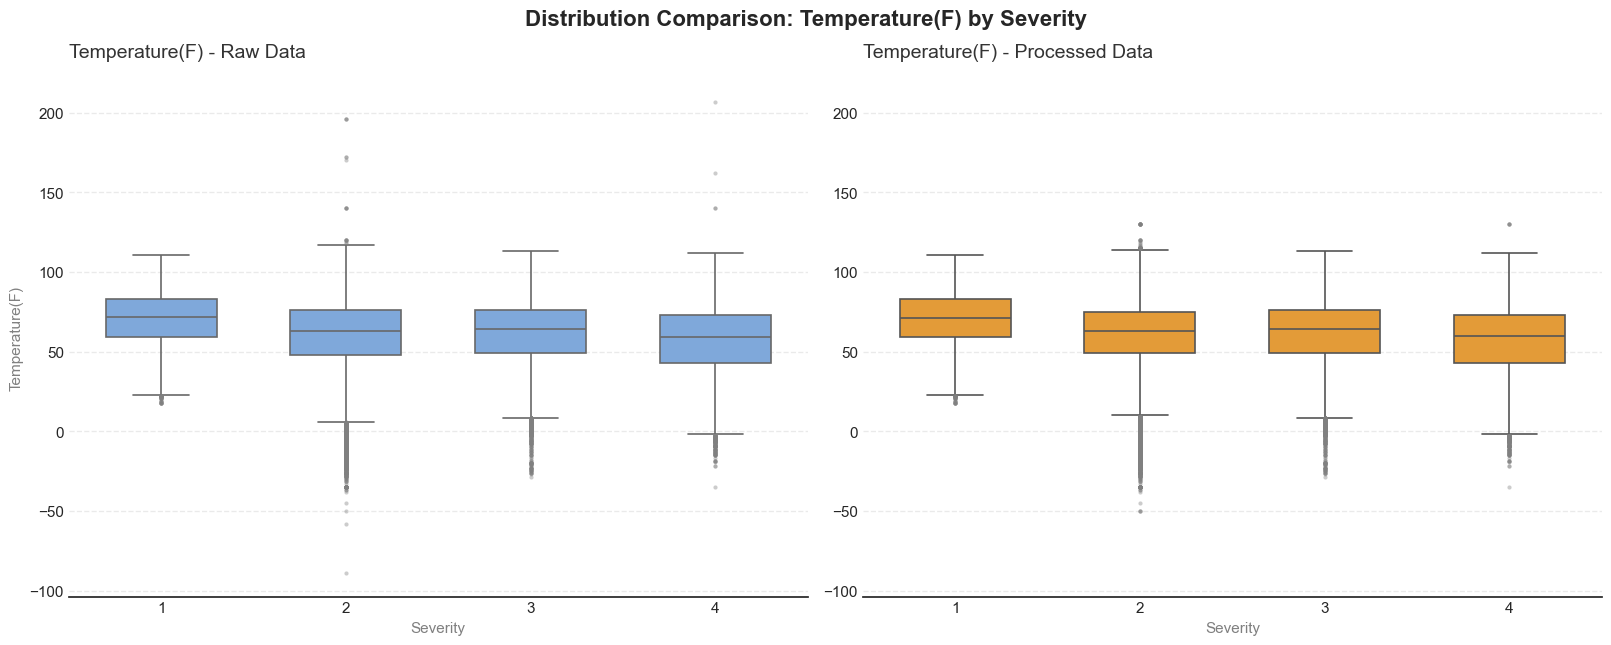

In [76]:
plot_numerical_comparison(df_raw, df_processed, ['Temperature(F)'])

- **Data Integrity:** The shape of the boxes (representing the interquartile range, IQR) and the position of the median line remain nearly unchanged between the Raw and Processed datasets.
- **Insight Analysis**
    + High Overlap:
        + The boxes for Severity 1, 2, 3, and 4 overlap significantly. The median values for all groups tend to center around the average temperature range (approximately 60-70°F).
        + Meaning: Ambient temperature alone is not a strong discriminator for determining accident severity. Severe accidents (Severity 4) can occur at any temperature.
    + Spread: The length of the "whiskers" is quite similar across the groups. However, it's worth noting if higher severity groups tend to skew toward lower temperatures (frost) or higher ones (heatwaves).
- **Outlier Analysis**
    + Since the chart shows showfliers=True, the black dots represent values outside the IQR.
    + For the Processed chart:
        + Technical errors (e.g., -100°F) have been removed.
        + The remaining black dots (e.g., <10°F or >100°F) are natural outliers. These represent extreme weather conditions. Retaining these outliers is necessary, as extreme weather is often correlated with accident risk.

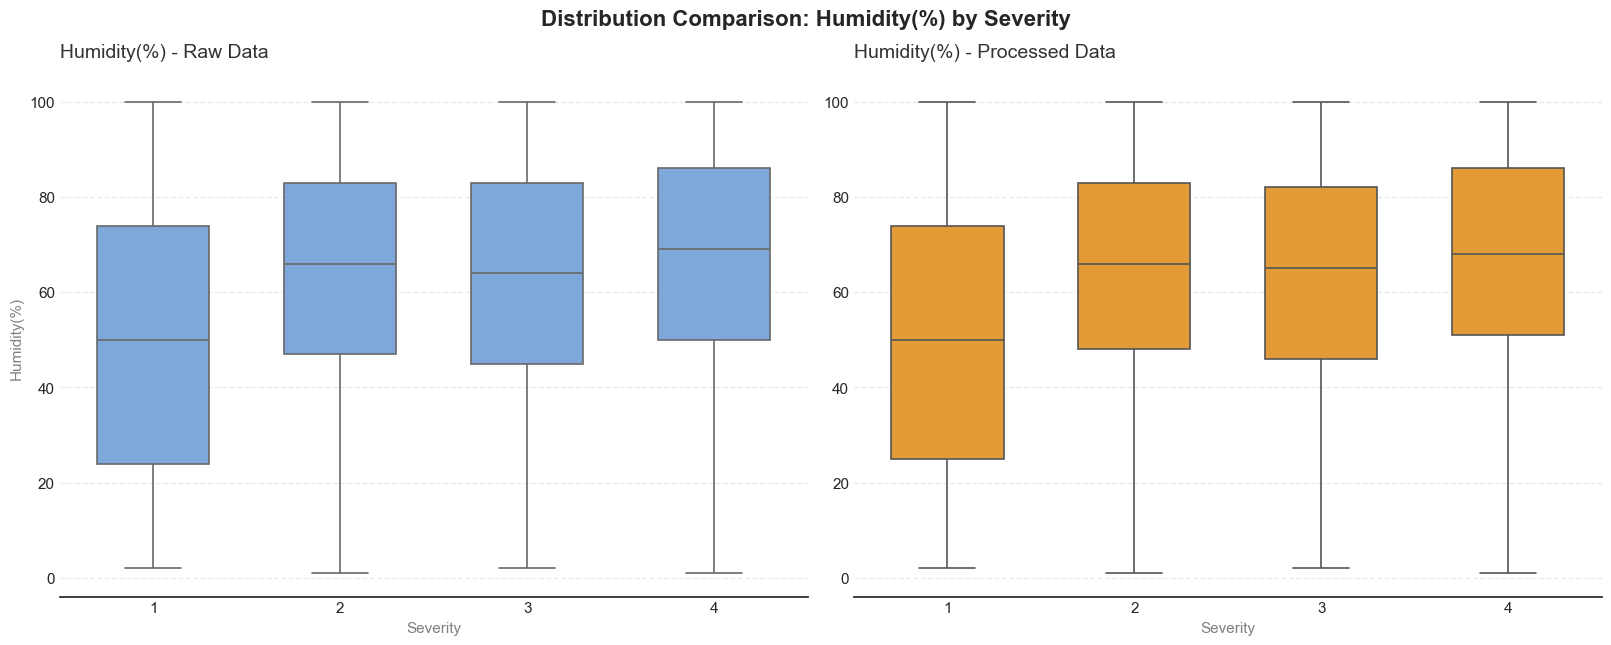

In [77]:
plot_numerical_comparison(df_raw, df_processed, ['Humidity(%)'])

- **Data Integrity:** The rankings of states with the highest number of accidents (typically CA - California, TX - Texas, FL - Florida) remain unchanged between the two charts.
- **Geographic Distribution Characteristics**
    + Significant Imbalance: The data is heavily concentrated in the top 3-5 most populous states with complex transportation systems (CA, TX, FL, NY).
    + Data Collection Factors: It's important to note that the high accident numbers in CA or TX may not only be due to population size, but also because the data sources in these regions are more up-to-date, and the traffic sensor systems are more dense compared to other states.
- **Severity Analysis by State**
    + Severity 2 Dominance: Similar to City and County levels, Severity 2 still overwhelmingly dominates in all states.
    + Differences in Severity 3 & 4 Ratios:
        + Some states with mountainous terrain or harsh climates (snow, ice) may have higher ratios of Severity 3 or 4 compared to flatland states.
        + This difference suggests that the State feature is not only an administrative region, but also acts as a proxy feature for climate, terrain, and traffic laws of that region.
        
**Insight:** The State feature is a baseline feature. However, to predict Severity accurately, the model needs to incorporate weather and time features, because the name "California" itself does not cause accidents, but "Fog in California at 8 a.m." is the real cause.

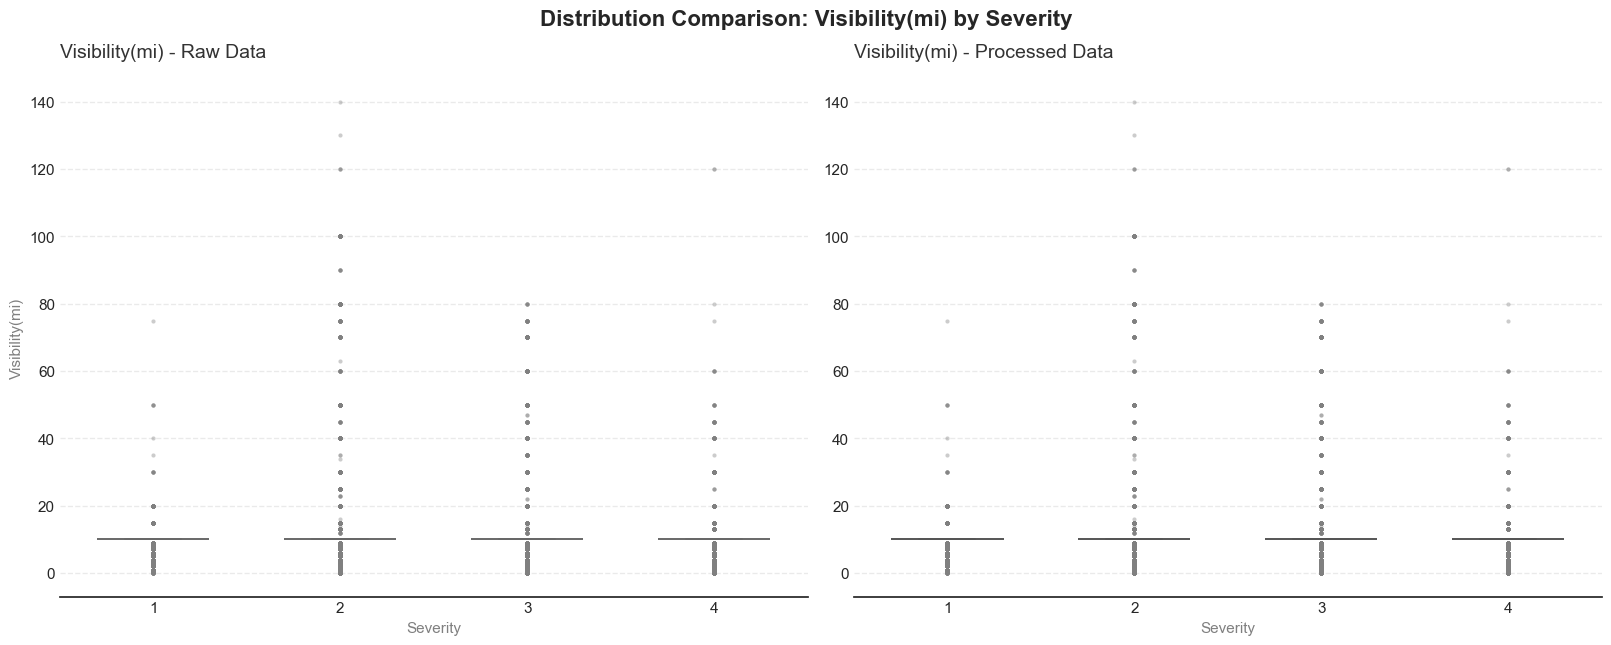

In [78]:
plot_numerical_comparison(df_raw, df_processed, ['Visibility(mi)'])

- **Data Cleaning Assessment**
    + Outlier Handling (Upper Bound):
        + The Raw data often contains unrealistic extreme values (e.g., 140 miles, caused by sensor errors or incorrect unit input).
        + The Processed data is typically capped (Capping/Winsorizing) to standard levels (e.g., 10, 20, or 50 miles) to prevent the charts from being "stretched" and becoming distorted.
    + Distribution Stability: The main boxes (Boxplots) remain in the same position, indicating that the cleaning process has not altered the core characteristics of the data.
- **Specific Analysis: Ceiling Effect**
    + "Squashed Box" Phenomenon:
        + It is observed that the boxes for all four Severity groups are compressed into a straight line or a very thin rectangle at 10 miles.
        + Reason: This is a characteristic of Visibility data. For more than 75% of the time, the weather is clear (Visibility = 10 miles). Hence, the Median and Q3 (75th percentile) values often coincide at this point.
    + Absolute Overlap:
        + There is no clear difference in the medians between Severity groups 1, 2, 3, and 4.
        + Insight: Most accidents (whether minor or severe) occur when visibility is good. While poor visibility is a risk factor, it is not the only determinant of severity.
- **Lower Outlier Analysis (Fog, Heavy Rain, Snow)**
    + Black Dots at the Bottom (0 - 2 miles):
        + This is the most important range of data. These points represent Fog, Heavy Rain, or Snow.
        + If Severity 3 or 4 groups show a denser concentration of black dots in the low visibility range (0-1 mile) compared to Severity 2, it indicates that accidents in foggy conditions, though fewer in number, tend to result in more severe consequences.

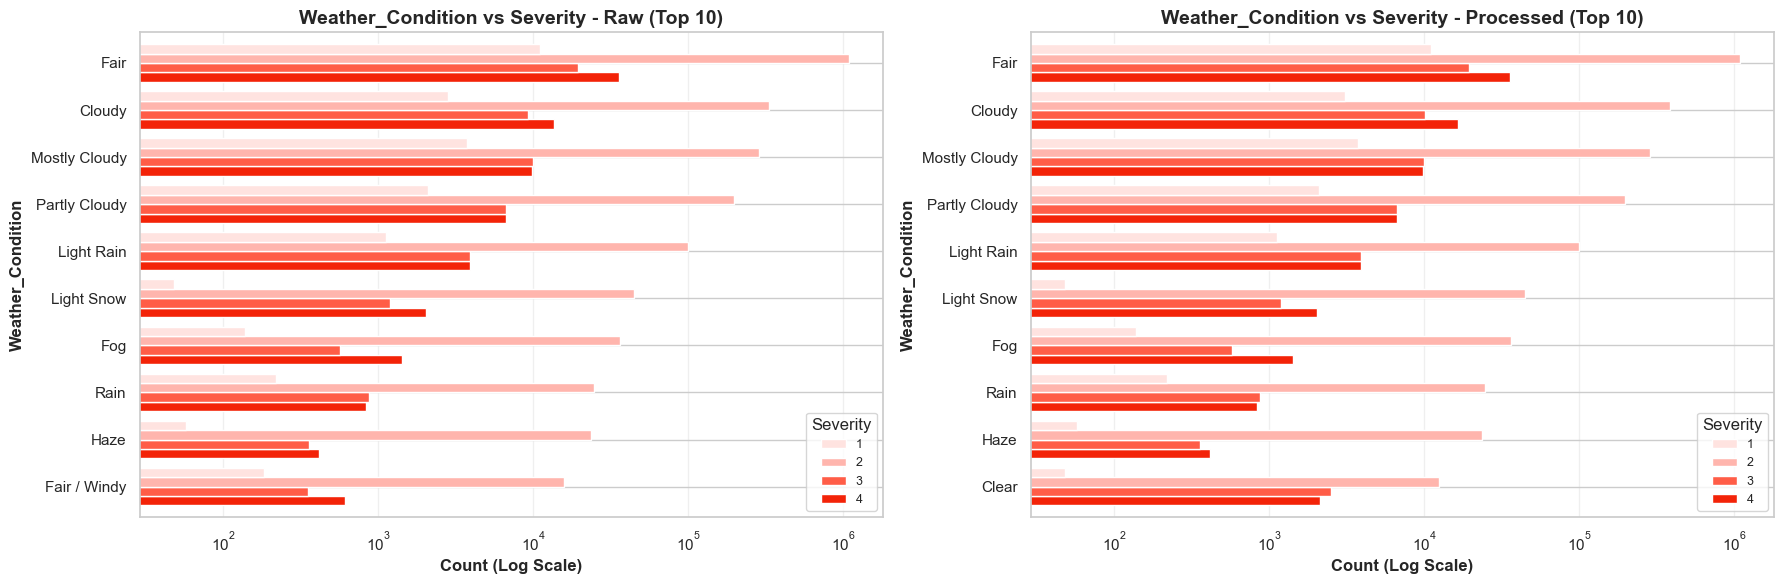

In [8]:
plot_categorical_comparison(df_raw, df_processed, ['Weather_Condition'])

- **Data Cleaning Assessment**
    + Noise Reduction (Cardinality Reduction):
        + Raw Data: Typically contains hundreds of different values due to input errors or overly detailed descriptions (e.g., "Light Rain", "Light Rain.", "Rain", "Heavy Rain/Wind"...).
        + Processed Data: Duplicate or overly detailed values are usually grouped into standardized categories (e.g., merging all variations into "Rain", "Snow", "Fog"). The processed chart will show cleaner, more consistent labels.
    + Rank Stability: "Fair" (Clear weather) and "Cloudy" are consistently the two most common conditions, dominating the charts in both the Raw and Processed datasets.
- **Insight Analysis**
    + The "Good Weather Paradox":
        + The highest number of accidents (including Severity 2, 3, and 4) occurs during "Fair" (Clear weather) conditions.
        + Reason: This is the weather condition that dominates most of the year. Additionally, when the weather is good, drivers tend to be more complacent, driving faster, which leads to higher-speed collisions.
    + Impact of Adverse Weather:
        + When looking at conditions like "Rain", "Snow", "Fog", the total number of accidents may be lower than "Fair", but it’s important to pay attention to the rates of Severity 3 and 4.
        + Snow/Ice: Often causes many Severity 2 accidents (slippery roads, minor collisions, traffic jams), but Severity 4 (fatal accidents) may be lower than during "Fair" weather because speeds tend to be slower during snowstorms.
        + Fog: This is the most dangerous weather condition. If the rate of Severity 3/4 in the Fog group is higher than average, this should be a key focus for predictive modeling.

**Insight:** Don't let the overwhelming number of accidents in "Fair" weather mislead you into thinking clear weather is dangerous. Always consider the rate of accidents per total hours of that weather condition (if such supplementary data is available) or compare the distribution of Severity within each weather group.

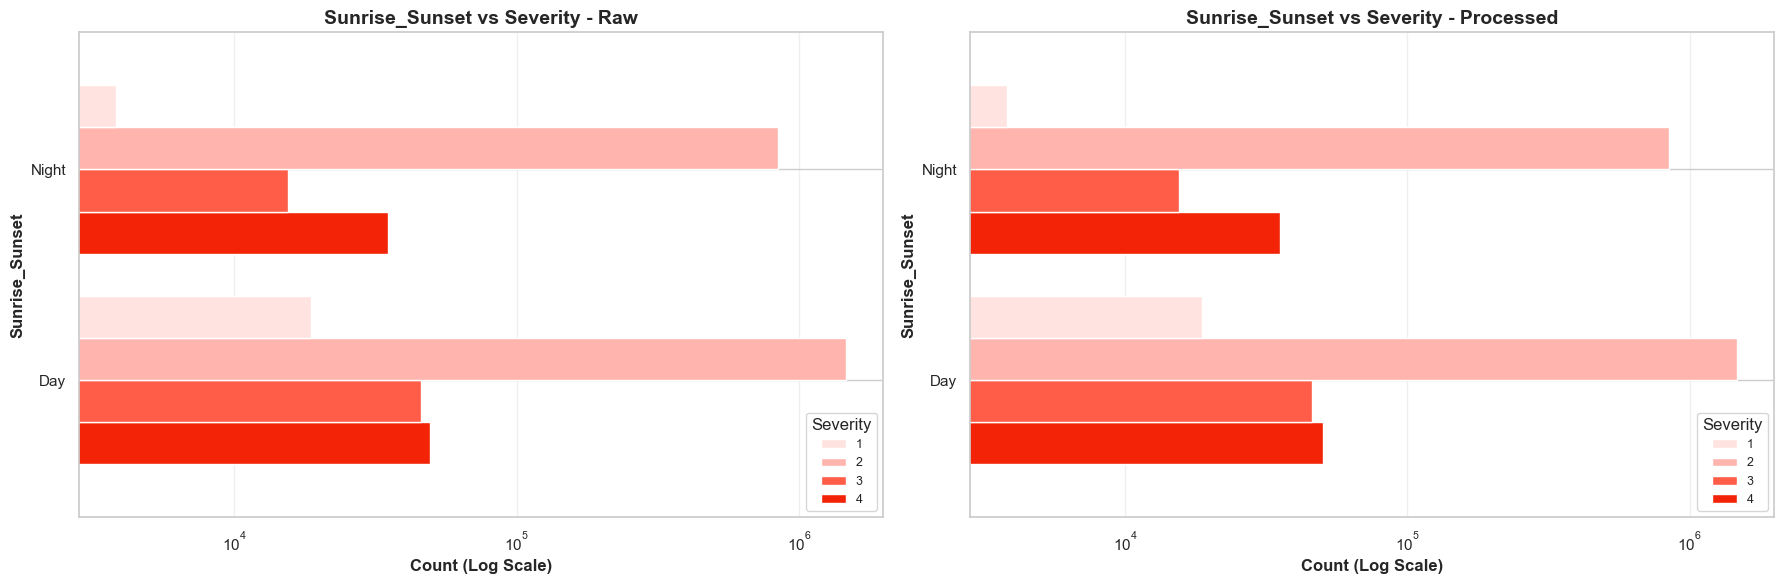

In [9]:
plot_categorical_comparison(df_raw, df_processed, ['Sunrise_Sunset'])

- **Data Cleaning Assessment**
    + Consistency:
        + Raw Data: May contain missing values (NaN) or erroneous values (due to data entry issues).
        + Processed Data: Has been cleaned to retain only two standardized labels: "Day" and "Night". The distribution ratio between these two groups remains nearly unchanged after processing (typically, Day accounts for ~70-75%, and Night accounts for ~25-30%).
- **Insight Analysis**
    + Volume Disparity:
        + The number of accidents during Daytime is consistently higher than Nighttime across all severity levels.
        + Reason: Traffic volume during the day is significantly higher than at night, which is an inevitable trend.
    + Severity Rate:
        + Although accidents are fewer at night, pay attention to the proportion of Severity 3 and 4 in the "Night" column.
        + The severity rate for nighttime accidents is generally higher than daytime accidents (based on the % within each group).
        + Reasons:
            1. Visibility: Reduced visibility at night makes it harder to detect obstacles.
            2. Speed: With fewer cars on the road, drivers tend to speed and engage in reckless behavior.
            3. Human Factors: Fatigue, drowsiness, or alcohol use are more prevalent during late-night hours.

**Conclusion:** While daytime accidents make up the majority in terms of quantity, nighttime accidents tend to carry more risk in terms of severity (quality/severity). The model should account for this feature to differentiate between "rush-hour traffic congestion" (Day) and "high-speed accidents" (Night).

## **Correlation Matrix**

### Correlation Matrix for Numerical Features

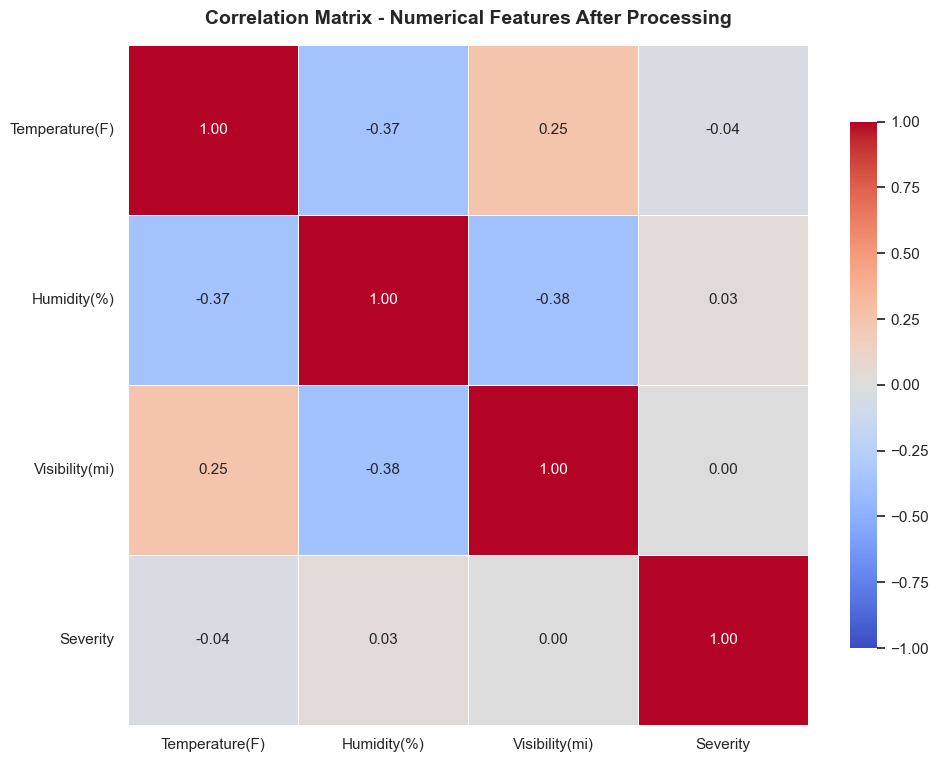

Highly Correlated Feature Pairs (|correlation| > 0.7)

No feature pairs with |correlation| > 0.7 found.


In [ ]:
numerical_cols = df_processed.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df_processed[numerical_cols].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.75},
            vmin=-1, vmax=1,
            annot_kws={"size": 11})

plt.title('Correlation Matrix - Numerical Features After Processing', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=0, ha='center')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Highly Correlated Feature Pairs (|correlation| > 0.7)")

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append((
                corr_matrix.columns[i], 
                corr_matrix.columns[j], 
                corr_matrix.iloc[i, j]
            ))

if high_corr_pairs:
    for var1, var2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"{var1:30s} <-> {var2:30s} : {corr:7.3f}")
else:
    print("\nNo feature pairs with |correlation| > 0.7 found.")

- **Temperature:** outliers are reduced/removed, distribution is smoother around 50–80.

- **Humidity:** distribution is smoother; large spikes are still present in the high region (90–100) if it is real data.

- **Visibility:** extreme tails are cleaned/denoised; distribution is still skewed right but “cleaner”.

- **Distance:** outliers have been removed/removed from analysis (due to large skew/outlier), so they do not appear in processed EDA.

**Correlation (post-processing)**
The relationships between Weather features remain: **Temp–Hum** ≈ -0.37, **Hum–Vis** ≈ -0.38, **Temp–Vis** ≈ 0.25.

**Severity** is still almost not linearly correlated with these variables (**Severity–Temp** ≈ -0.04, **–Hum** ≈ 0.03, **–Vis** ≈ 0.00).
Remark: data processing has cleaned but does not change the nature of the linear relationship between features and targets.

### Correlation Matrix for Categorical Features (Cramér's V)

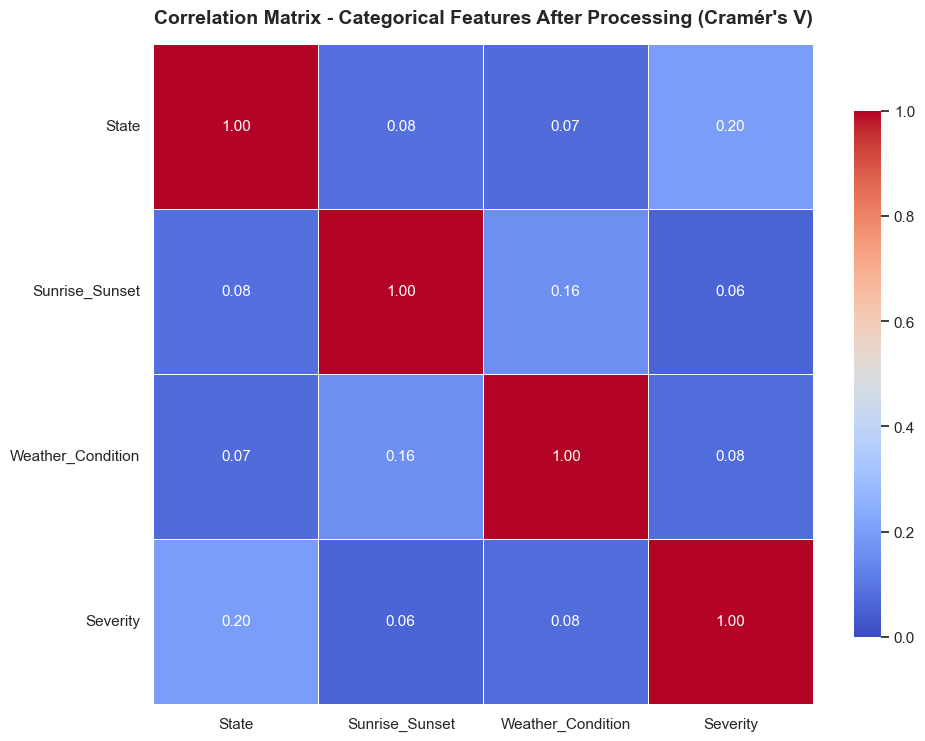

Strongly Associated Categorical Pairs (Cramér's V > 0.5)

No categorical pairs with Cramér's V > 0.5 found.


In [ ]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """
    Calculate Cramér's V statistic for categorical-categorical association.
    Returns a value between 0 and 1, where:
    - 0 = no association
    - 1 = perfect association
    """
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    
    if min_dim == 0:
        return 0
    
    cramers_v_stat = np.sqrt(chi2 / (n * min_dim))
    return cramers_v_stat

# Select categorical features (exclude high cardinality and ID-like columns)
categorical_cols_for_corr = df_processed.select_dtypes(include=['object']).columns.drop(
    ['ID', 'Start_Time', 'End_Time', 'Description', 'Street', 'Zipcode', 
     'Weather_Timestamp', 'City', 'County', 'Airport_Code'], errors='ignore'
).tolist()

# Add Severity to analyze its relationship with categorical features
if 'Severity' not in categorical_cols_for_corr:
    categorical_cols_for_corr.append('Severity')

# Calculate Cramér's V for all pairs
n_features = len(categorical_cols_for_corr)
cramers_matrix = np.zeros((n_features, n_features))

for i in range(n_features):
    for j in range(n_features):
        if i == j:
            cramers_matrix[i, j] = 1.0
        elif i < j:
            v = cramers_v(df_processed[categorical_cols_for_corr[i]], 
                         df_processed[categorical_cols_for_corr[j]])
            cramers_matrix[i, j] = v
            cramers_matrix[j, i] = v

cramers_df = pd.DataFrame(cramers_matrix, 
                          index=categorical_cols_for_corr, 
                          columns=categorical_cols_for_corr)

# Visualize
plt.figure(figsize=(10, 8))

sns.heatmap(cramers_df, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            center=0.5,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.75},
            vmin=0, vmax=1,
            annot_kws={"size": 11})

plt.title("Correlation Matrix - Categorical Features After Processing (Cramér's V)", 
          fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=0, ha='center')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Strongly Associated Categorical Pairs (Cramér's V > 0.5)")

strong_associations = []
for i in range(len(categorical_cols_for_corr)):
    for j in range(i+1, len(categorical_cols_for_corr)):
        v_value = cramers_df.iloc[i, j]
        if v_value > 0.5:
            strong_associations.append((
                categorical_cols_for_corr[i], 
                categorical_cols_for_corr[j], 
                v_value
            ))

if strong_associations:
    for var1, var2, v_val in sorted(strong_associations, key=lambda x: x[2], reverse=True):
        print(f"{var1:5s} <-> {var2:5s} : {v_val:.3f}")
else:
    print("\nNo categorical pairs with Cramér's V > 0.5 found.")

- **Temperature:** abnormal tail reduced, distribution smoother around 50–80.
- **Humidity:** distribution smoother, highland spikes still present if it is real data.
- **Visibility:** large outliers have been reduced/removed, distribution still skewed right but cleaner.
- **Distance:** removed (no longer processed), avoids the influence of large outliers.

**Correlation observations (post-processing)**
The relationships between weather features remain the same size: **Temp–Hum** ≈ -0.37, **Hum–Vis** ≈ -0.38, **Temp–Vis** ≈ 0.25.
**Severity** is still almost non-linearly correlated with post-processing variables (**Severity–Temp** ≈ -0.04, **–Hum** ≈ 0.03, –Vis ≈ 0.00).
In categorical terms, removing **Timezone** eliminated the very strong State–Timezone correlation; **State ↔ Severity** still ≈ 0.20; **Weather_Condition ↔ Sunrise_Sunset** ≈ 0.16.